In [44]:
import os
from glob import glob
import numpy as np
from spectral.io import envi
from spectral_util import mosaic, spec_io
import pyproj
from osgeo import osr
from itertools import product
from isofit.utils import skyview
import matplotlib.pyplot as plt

import sys
sys.path.append('/store/carroll/repos/chess-isofit')
from utilities import *

os.chdir('/store/carroll/col/data/2018/')

%matplotlib widget

In [38]:
fp = '/store/carroll/col/data/2018/raw/L1/2018061914/NIS01_20180619_162542_loc_dtm.hdr'
loc_dtm = envi.open(fp).open_memmap()
loc_dtm.shape

(23727, 1675, 3)

In [41]:
tmp = loc_dtm[...,2]
len(tmp[np.isnan(tmp)])

36237

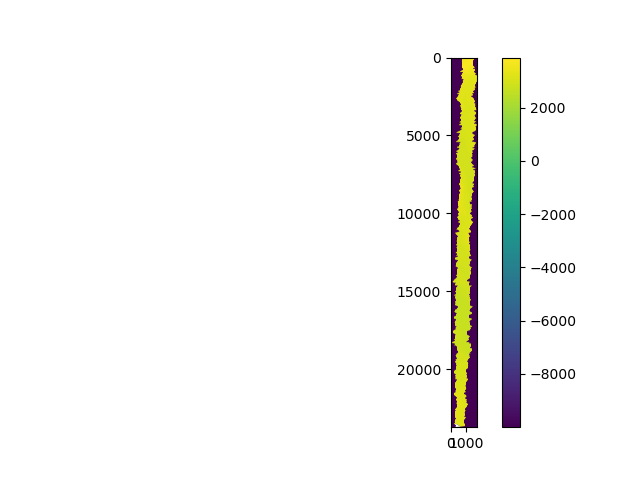

In [45]:
fig = plt.figure()
plt.imshow(tmp)
plt.colorbar()
plt.show()

In [29]:
fid = 'NIS01_20180612_155442'
nodata=-9999

In [31]:
fp_dtm = f'raw/L3/discreteLidar/DTM/{fid}_dtm.hdr'
fp_loc = glob(f'raw/L1/*/{fid}_rdn_ort_igm_ort.hdr')[0]
fp_obs = glob(f'raw/L1/*/{fid}_rdn_obs_ort.hdr')[0]

dtm = envi.open(fp_dtm).open_memmap()[...,0].copy()
loc = envi.open(fp_loc).open_memmap().copy()
obs = envi.open(fp_obs).open_memmap().copy()
na_mask = loc[...,2]==nodata

dtm.shape, loc.shape, obs.shape, na_mask.shape

((3809, 1311), (3809, 1311, 3), (3809, 1311, 11), (3809, 1311))

In [34]:
slope, aspect = skyview.gradient_d8(dtm, dx=1, dy=1, aspect_rad=True) # slope, aspect in rad
slope.shape, aspect.shape

((3809, 1311), (3809, 1311))

In [35]:
# calculate cos i
solar_az = np.radians(obs[...,3])
solar_zen = np.radians(obs[...,4])
cos_i = (np.cos(solar_zen) * np.cos(slope) + np.sin(solar_zen) * np.sin(slope) * np.cos(solar_az - aspect))
cos_i.shape

(3809, 1311)

In [3]:
fp = 'raw/L1/2018061214/NIS01_20180612_155442_rdn_obs_ort.hdr'

output_epsg = 32613
gproj = osr.SpatialReference()
gproj.ImportFromEPSG(int(output_epsg))
wkt = gproj.ExportToWkt()
proj = pyproj.Proj(f"epsg:{output_epsg}")

ul_lr = spec_io.get_extent_from_obs(fp)
ul = proj(ul_lr[0], ul_lr[1])
lr = proj(ul_lr[2], ul_lr[3])
ul_lr = [ul[0], ul[1], lr[0], lr[1]]
ul_lr

[335608.00000000023, 4310919.999999999, 336918.9999999991, 4307110.999999999]

In [15]:
x_min = (ul[0] // 1000) * 1000
x_max = (lr[0] // 1000) * 1000
x_grids = list(np.arange(x_min, x_max+1, 1000))

y_min = (lr[1] // 1000) * 1000
y_max = (ul[1] // 1000) * 1000
y_grids = list(np.arange(y_min, y_max+1, 1000))

x_grids, y_grids

([335000.0, 336000.0], [4307000.0, 4308000.0, 4309000.0, 4310000.0])

In [21]:
tiles = [f'{int(x)}_{int(y)}' for x, y in product(x_grids, y_grids)]
tiles

['335000_4307000',
 '335000_4308000',
 '335000_4309000',
 '335000_4310000',
 '336000_4307000',
 '336000_4308000',
 '336000_4309000',
 '336000_4310000']

In [25]:
fid = 'NIS01_20180612_155442'
fp_mosaic = '/store/carroll/col/data/2018/raw/L3/discreteLidar/DTM/dtm_mosaic_crbu_2018.tif'
fp_ref = glob(f'/store/carroll/col/data/2018/raw/L1/*/{fid}_rdn_ort_igm_ort')[0]
fp_out = f'/store/carroll/col/data/2018/raw/L3/discreteLidar/DTM/{fid}_dtm'

clip_skyview_per_flightline(fp_mosaic, fp_ref, fp_out)

In [ ]:
def clip_skyview_per_flightline(fp_skyview, fp_ref, fp_out):
    """
    Resample a campaign-wide skyview factor to the geoemtry of individual flightlines
    """
    with rasterio.open(fp_ref) as ref, rasterio.open(fp_skyview) as skyview:    
        dst = np.full((1, ref.height, ref.width),
                      ref.nodata if ref.nodata is not None else np.nan,
                      dtype=np.float32)
    
        reproject(
            source=rasterio.band(skyview, 1),
            destination=dst[0],
            src_transform=skyview.transform,
            src_crs=skyview.crs,
            src_nodata=skyview.nodata,
            dst_transform=ref.transform,
            dst_crs=ref.crs,
            dst_nodata=skyview.nodata if skyview.nodata is not None else -9999,
            resampling=Resampling.bilinear,
        )
    
        profile_out = ref.profile
        profile_out.update(
            dtype=dst.dtype,
            count=1,
            nodata=skyview.nodata if skyview.nodata is not None else -9999,
            interleave='bil'
        )
        with rasterio.open(fp_out, 'w', **profile_out) as dst_ds:
            dst_ds.write(dst)